# PyTorch FashionMNIST Classification

## Phase 0 - Define Problem
The primary objective of this project is to develop a machine learning model capable of accurately classifying images of clothing from the FashionMNIST dataset. This task is fundamentally a multi-class classification problem within the domain of supervised learning, where the network must learn to assign each input data point to one of the predefined apparel categories. To accomplish this, we will design and build an artificial neural network utilizing the PyTorch framework. By training this model, it will learn to map the raw pixel data of the images to their corresponding class labels, allowing us to eventually evaluate its predictive accuracy and generalization capabilities on unseen test data

## Phase 1 — Environment Setup

In [1]:
import sys
import os
from pathlib import Path

CURRENT_DIR = Path.cwd()
PARENT_DIR = CURRENT_DIR.parent.parent

if str(PARENT_DIR) not in sys.path:
    sys.path.append(str(PARENT_DIR))

In [2]:
%matplotlib inline
import sys
import torch
import torchvision
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

Python version: 3.11.9
PyTorch version: 2.5.1+cu121
TorchVision version: 0.20.1+cu121
CUDA available: True
MPS available: False


In [3]:
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torch.utils.tensorboard import SummaryWriter
from typing import List, Optional

## Phase 2 — Data Loading

In [4]:
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

## Phase 3 - EDA

### Data Overview

In [ ]:
print(f"Số lượng ảnh tập Train: {len(train_dataset)}")
print(f"Số lượng ảnh tập Test: {len(test_dataset)}")

Số lượng ảnh tập Train: 60000
Số lượng ảnh tập Test: 10000


In [5]:
image, label = train_dataset[0]
channels, height, width = image.shape
aspect_ratio = width / height

In [6]:
print(f" - Độ phân giải (Resolution): {width}x{height} pixels")
print(f" - Tỷ lệ khung hình (Aspect Ratio): {width}:{height} (Tương đương {aspect_ratio:.1f}:1)")

 - Độ phân giải (Resolution): 28x28 pixels
 - Tỷ lệ khung hình (Aspect Ratio): 28:28 (Tương đương 1.0:1)


In [7]:
print(f"Kích thước của một bức ảnh (Channels x Height x Width): {image.shape}")
print(f"Kiểu dữ liệu của ảnh: {image.dtype}")

Kích thước của một bức ảnh (Channels x Height x Width): torch.Size([1, 28, 28])
Kiểu dữ liệu của ảnh: torch.float32


In [8]:
if channels == 1:
    print(f" - Kênh màu (Color Channels): {channels} (Định dạng Grayscale - Ảnh xám)")
elif channels == 3:
    print(f" - Kênh màu (Color Channels): {channels} (Định dạng RGB - Ảnh màu)")
else:
    print(f" - Kênh màu (Color Channels): {channels} (Định dạng bất thường)")

 - Kênh màu (Color Channels): 1 (Định dạng Grayscale - Ảnh xám)


### Univariate Analysis

In [9]:
train_labels = [label for _, label in train_dataset]
class_counts = Counter(train_labels)

In [10]:
for class_idx, count in sorted(class_counts.items()):
    class_name = train_dataset.classes[class_idx]
    print(f" - Class {class_idx} ({class_name}): {count} ảnh")

 - Class 0 (T-shirt/top): 6000 ảnh
 - Class 1 (Trouser): 6000 ảnh
 - Class 2 (Pullover): 6000 ảnh
 - Class 3 (Dress): 6000 ảnh
 - Class 4 (Coat): 6000 ảnh
 - Class 5 (Sandal): 6000 ảnh
 - Class 6 (Shirt): 6000 ảnh
 - Class 7 (Sneaker): 6000 ảnh
 - Class 8 (Bag): 6000 ảnh
 - Class 9 (Ankle boot): 6000 ảnh


In [11]:
all_images = torch.stack([img for img, _ in train_dataset])
mean_val = all_images.mean().item()
std_val = all_images.std().item()

In [12]:
print(f"\nGiá trị Pixel Trung bình (Mean): {mean_val:.4f}")
print(f"Độ lệch chuẩn Pixel (Std): {std_val:.4f}")


Giá trị Pixel Trung bình (Mean): 0.2860
Độ lệch chuẩn Pixel (Std): 0.3530


In [13]:
corrupted_count = 0
nan_images = 0
black_images = 0
white_images = 0

In [14]:
for idx in range(len(train_dataset)):
    img, _ = train_dataset[idx]
    
    # NaN - Not a Number
    if torch.isnan(img).any():
        nan_images += 1
        corrupted_count += 1
        
    # Tất cả pixel đều có giá trị bằng 0
    elif torch.max(img) == 0.0:
        black_images += 1
        corrupted_count += 1
        
    # Tất cả pixel đều bằng 1.0 do đã ToTensor
    elif torch.min(img) == 1.0:
        white_images += 1
        corrupted_count += 1

In [15]:
print(f"Tổng số ảnh trong tập Train: {len(train_dataset)} ảnh")
print(f"Số lượng ảnh phát hiện bị lỗi: {corrupted_count} ảnh")

Tổng số ảnh trong tập Train: 60000 ảnh
Số lượng ảnh phát hiện bị lỗi: 0 ảnh


### Bivariate Analysis

In [ ]:
train_loader_sample = torch.utils.data.DataLoader(train_dataset, batch_size=20, shuffle=True)
dataiter = iter(train_loader_sample)
images, labels = next(dataiter)
class_names = train_dataset.classes

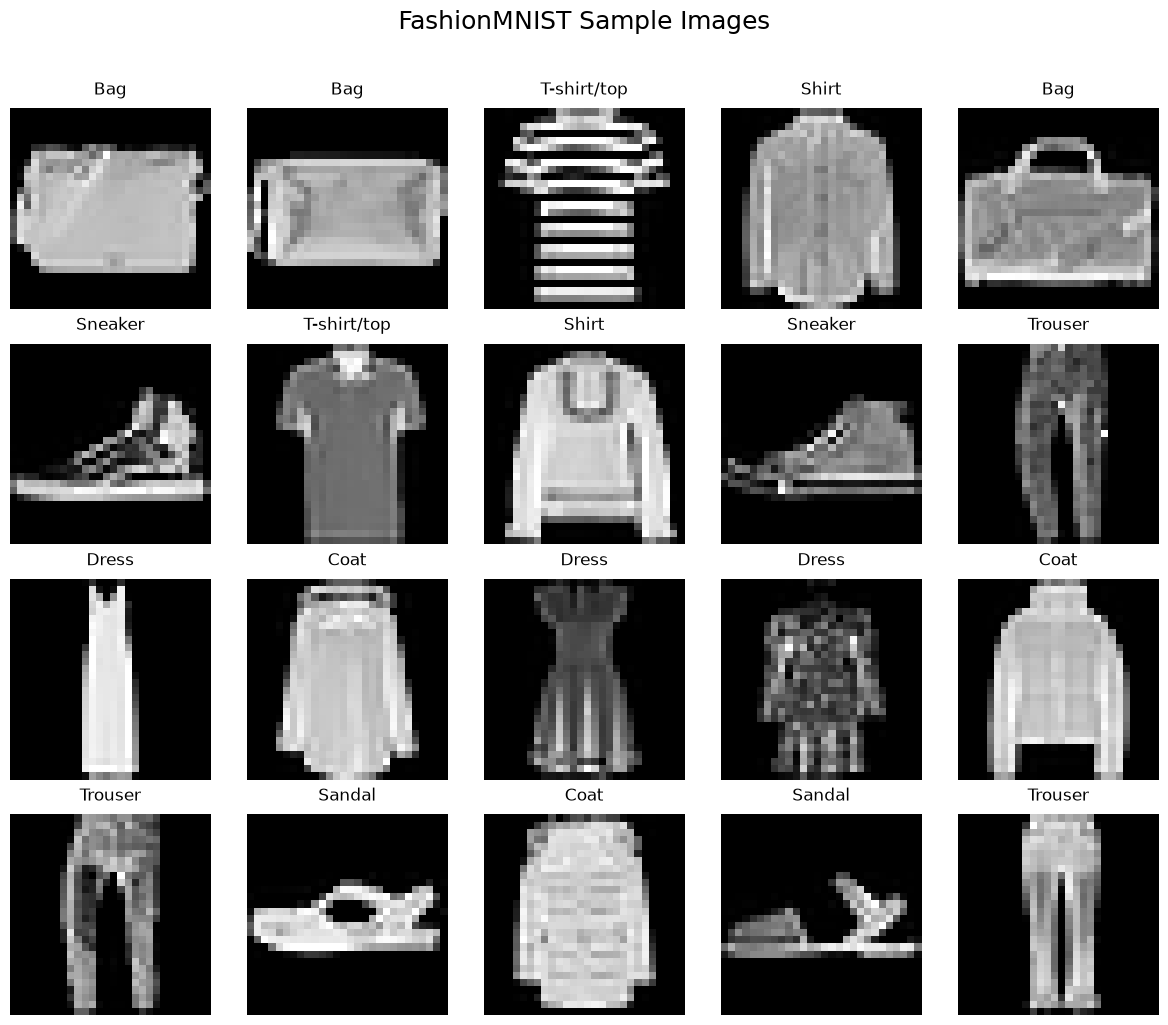

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(12, 10))
fig.suptitle('FashionMNIST Sample Images', fontsize=18, y=1.02)

for idx, ax in enumerate(axes.flatten()):
    img = images[idx].squeeze().numpy()
    label_name = class_names[labels[idx]]
    
    ax.imshow(img, cmap='gray')
    
    ax.set_title(label_name, fontsize=12, pad=10)
    
    ax.axis('off')

plt.tight_layout()
plt.show()

## Phase 4 — Data Preprocessing

In [17]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),                
    transforms.Normalize((0.5,), (0.5,))  
])

In [18]:
test_transform = transforms.Compose([
    transforms.ToTensor(),                
    transforms.Normalize((0.5,), (0.5,))  
])

In [19]:
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=test_transform)

In [20]:
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [21]:
print(f"Số lượng lô (batches) trong tập Train: {len(train_loader)} (với mỗi lô chứa 64 ảnh)")
print(f"Số lượng lô (batches) trong tập Test: {len(test_loader)}")

Số lượng lô (batches) trong tập Train: 938 (với mỗi lô chứa 64 ảnh)
Số lượng lô (batches) trong tập Test: 157


In [22]:
dataiter = iter(train_loader)
images, labels = next(dataiter)
print(f"\nKích thước của một batch ảnh (Batch_size x Channels x Height x Width): {images.shape}")
print(f"Kích thước của nhãn (Labels): {labels.shape}")


Kích thước của một batch ảnh (Batch_size x Channels x Height x Width): torch.Size([64, 1, 28, 28])
Kích thước của nhãn (Labels): torch.Size([64])


## Phase 5 - Model Building

In [23]:
class FashionMNISTModel(nn.Module):
    def __init__(
        self,
        hidden_dims: Optional[List[int]] = None,
        dropout: float = 0.0,
        num_classes: int = 10,
        input_dim: int = 28 * 28
    ):
        super(FashionMNISTModel, self).__init__()
        
        if hidden_dims is None:
            hidden_dims = [128]

        layers: List[nn.Module] = []
        
        layers.append(nn.Flatten())
        
        in_features = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_features, hidden_dim))
            layers.append(nn.ReLU())
            
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
                
            in_features = hidden_dim
            
        layers.append(nn.Linear(in_features, num_classes))

        self.network = nn.Sequential(*layers)
        self.num_classes = num_classes

    def forward(self, x):
        if not isinstance(x, torch.Tensor):
            raise TypeError(f"[LỖI INPUT] Dữ liệu đầu vào bắt buộc phải là torch.Tensor. Nhận được: {type(x)}")
        
        if x.dtype not in [torch.float32, torch.float64]:
            raise TypeError(f"[LỖI INPUT] Dữ liệu Tensor phải mang kiểu số thực (Float). Nhận được: {x.dtype}")

        out = self.network(x)
        
        if not isinstance(out, torch.Tensor):
            raise TypeError(f"[LỖI OUTPUT] Đầu ra dự kiến là torch.Tensor. Nhận được: {type(out)}")

        if out.shape[1] != 10:
            raise ValueError(f"[LỖI OUTPUT] Mô hình phải trả ra 10 giá trị dự đoán cho 10 class. Hiện tại trả ra: {out.shape[1]}")

        return out

In [24]:
model = FashionMNISTModel()

dummy_valid_input = torch.randn(64, 1, 28, 28, dtype=torch.float32)

In [25]:
try:
    dummy_output = model(dummy_valid_input)
    print(f"✅ Pass! Mô hình chạy thành công. Kích thước output: {dummy_output.shape}")
except Exception as e:
    print(f"❌ Failed! Lỗi: {e}")

✅ Pass! Mô hình chạy thành công. Kích thước output: torch.Size([64, 10])


## Phase 6 - Model Training

In [26]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size 

In [27]:
# Data Split
gen = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    train_dataset, 
    [train_size, val_size], 
    generator=gen
)

In [28]:
print(f"Kích thước tập Train mới: {len(train_dataset)} ảnh")
print(f"Kích thước tập Validation: {len(val_dataset)} ảnh")
print(f"Kích thước tập Test: {len(test_dataset)} ảnh")

Kích thước tập Train mới: 48000 ảnh
Kích thước tập Validation: 12000 ảnh
Kích thước tập Test: 10000 ảnh


In [29]:
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)

In [30]:
import torch.optim as optim

In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

FashionMNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [33]:
writer = SummaryWriter('runs/fashion_mnist_experiment_1')

In [34]:
def validate(model: FashionMNISTModel, dataloader: DataLoader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad():
        for data, labels in dataloader:
            data = data.to(device)
            labels =  labels.to(device)
            
            outputs = model(data)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            predicted_labels = torch.max(outputs.data, 1)[1]
            total_samples += labels.size(0)
            correct_predictions += (predicted_labels == labels).sum().item()
            
    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct_predictions / total_samples
    
    return avg_loss, accuracy

In [35]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

In [36]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for batch_idx, (data, labels) in enumerate(train_loader):
        data = data.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
        predicted_labels = torch.max(outputs.data, 1)[1]
        total_train += labels.size(0)
        correct_train += (predicted_labels == labels).sum().item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train
    
    val_loss, val_accuracy = validate(model, val_loader, criterion, device)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"| Train Loss: {avg_train_loss:.4f} (Acc: {train_accuracy:.2f}%) "
          f"| Val Loss: {val_loss:.4f} (Acc: {val_accuracy:.2f}%)")
    
    writer.add_scalar('Loss/Train', avg_train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('Accuracy/Train', train_accuracy, epoch)
    writer.add_scalar('Accuracy/Validation', val_accuracy, epoch)
    
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

writer.close()

Epoch [1/10] | Train Loss: 0.5894 (Acc: 78.68%) | Val Loss: 0.4798 (Acc: 82.50%)
Epoch [2/10] | Train Loss: 0.4571 (Acc: 83.38%) | Val Loss: 0.4370 (Acc: 83.96%)
Epoch [3/10] | Train Loss: 0.4215 (Acc: 84.51%) | Val Loss: 0.4011 (Acc: 85.45%)
Epoch [4/10] | Train Loss: 0.4029 (Acc: 85.25%) | Val Loss: 0.3981 (Acc: 85.41%)
Epoch [5/10] | Train Loss: 0.3865 (Acc: 85.76%) | Val Loss: 0.3891 (Acc: 85.38%)
Epoch [6/10] | Train Loss: 0.3763 (Acc: 86.12%) | Val Loss: 0.3613 (Acc: 87.05%)
Epoch [7/10] | Train Loss: 0.3665 (Acc: 86.53%) | Val Loss: 0.3711 (Acc: 86.31%)
Epoch [8/10] | Train Loss: 0.3607 (Acc: 86.76%) | Val Loss: 0.3485 (Acc: 87.19%)
Epoch [9/10] | Train Loss: 0.3516 (Acc: 86.99%) | Val Loss: 0.3494 (Acc: 87.20%)
Epoch [10/10] | Train Loss: 0.3489 (Acc: 87.19%) | Val Loss: 0.3498 (Acc: 86.92%)


In [ ]:
%load_ext tensorboard
%tensorboard --logdir runs

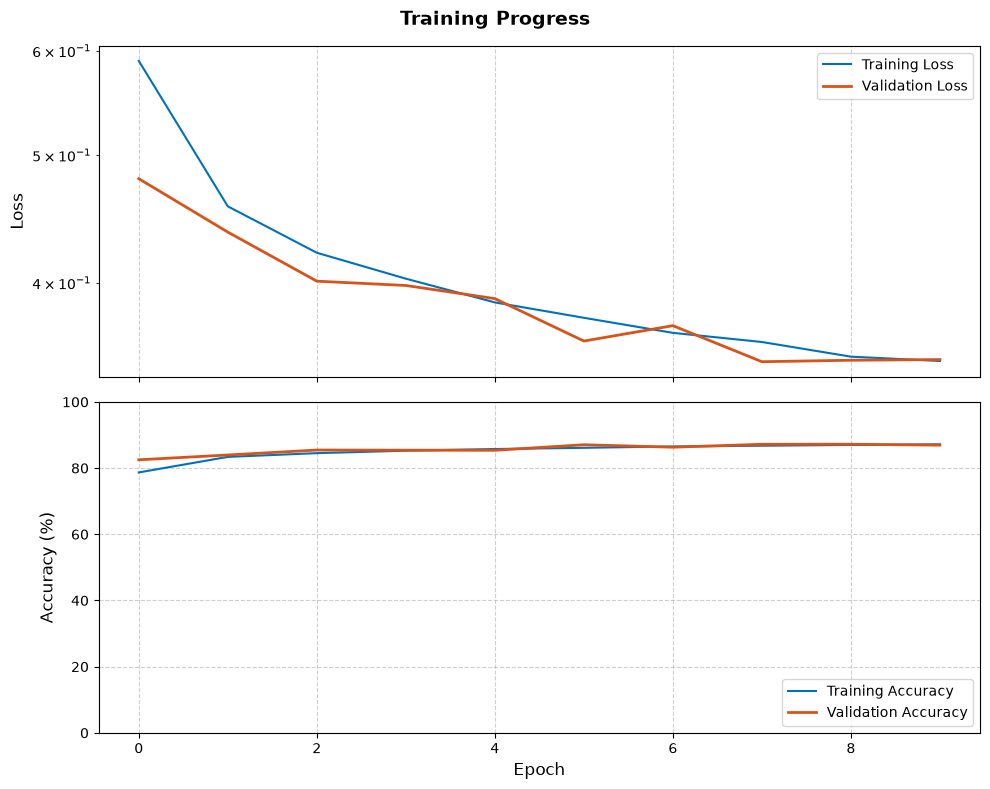

In [37]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Training Progress', fontsize=14, fontweight='bold')

ax1.plot(train_losses, label='Training Loss', color='#0072BD', linewidth=1.5)
ax1.plot(val_losses, label='Validation Loss', color='#D95319', linewidth=2)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_yscale('log') 
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

ax2.plot(train_accuracies, label='Training Accuracy', color='#0072BD', linewidth=1.5)
ax2.plot(val_accuracies, label='Validation Accuracy', color='#D95319', linewidth=2)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylim([0, 100])
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

## Phase 7 - Model Evaluation

In [38]:
model.eval()

test_loss = 0.0
correct_test = 0
total_test = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        labels = labels.to(device)
        
        outputs = model(data)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

avg_test_loss = test_loss / len(test_loader)
test_acc = 100 * correct_test / total_test

In [39]:
print(f" - Test Loss: {avg_test_loss:.4f}")
print(f" - Test Accuracy (Tổng thể): {test_acc:.2f}%\n")

 - Test Loss: 0.3806
 - Test Accuracy (Tổng thể): 86.52%



In [40]:
class_names = test_dataset.classes 
print("📊 BÁO CÁO PHÂN LOẠI CHI TIẾT:")
print(classification_report(all_targets, all_preds, target_names=class_names))

📊 BÁO CÁO PHÂN LOẠI CHI TIẾT:
              precision    recall  f1-score   support

 T-shirt/top       0.76      0.88      0.82      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.78      0.76      0.77      1000
       Dress       0.88      0.84      0.86      1000
        Coat       0.74      0.82      0.78      1000
      Sandal       0.96      0.94      0.95      1000
       Shirt       0.73      0.61      0.66      1000
     Sneaker       0.92      0.93      0.92      1000
         Bag       0.97      0.95      0.96      1000
  Ankle boot       0.94      0.96      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.86     10000
weighted avg       0.87      0.87      0.86     10000



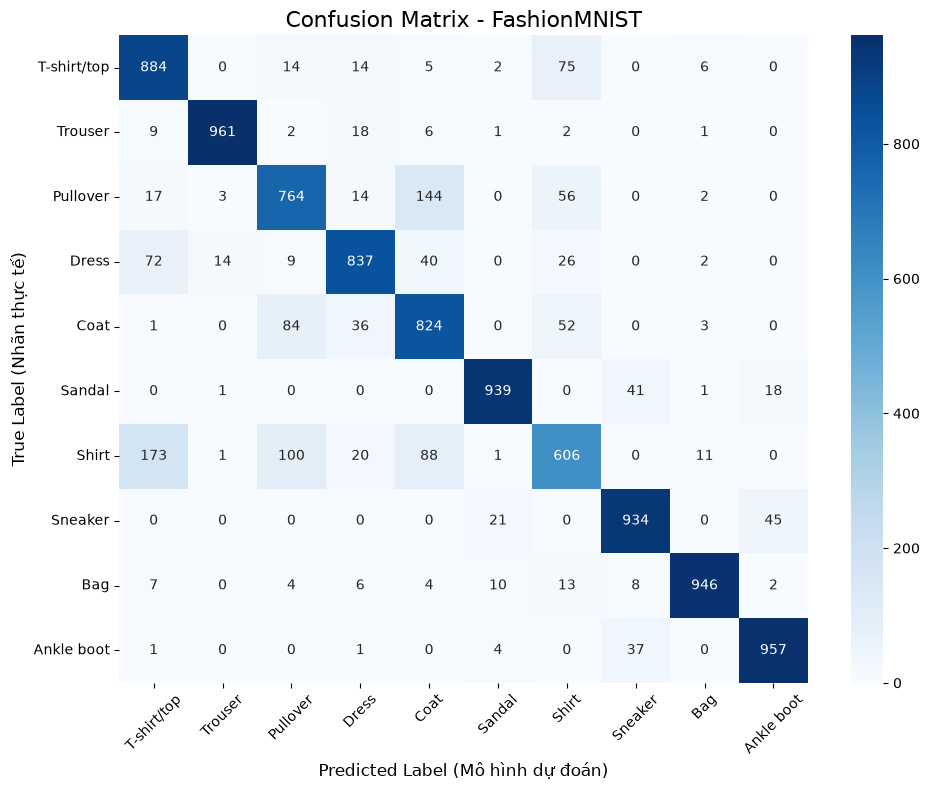

In [41]:
cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - FashionMNIST', fontsize=16)
plt.xlabel('Predicted Label (Mô hình dự đoán)', fontsize=12)
plt.ylabel('True Label (Nhãn thực tế)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Phase 8 - Save Model & Visualization

In [42]:
MODEL_PATH = "fashion_mnist_model.pth"

# Lưu state_dict của mô hình
torch.save(model.state_dict(), MODEL_PATH)

In [43]:
loaded_model = FashionMNISTModel()

loaded_model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))

loaded_model.to(device)
loaded_model.eval()

FashionMNISTModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

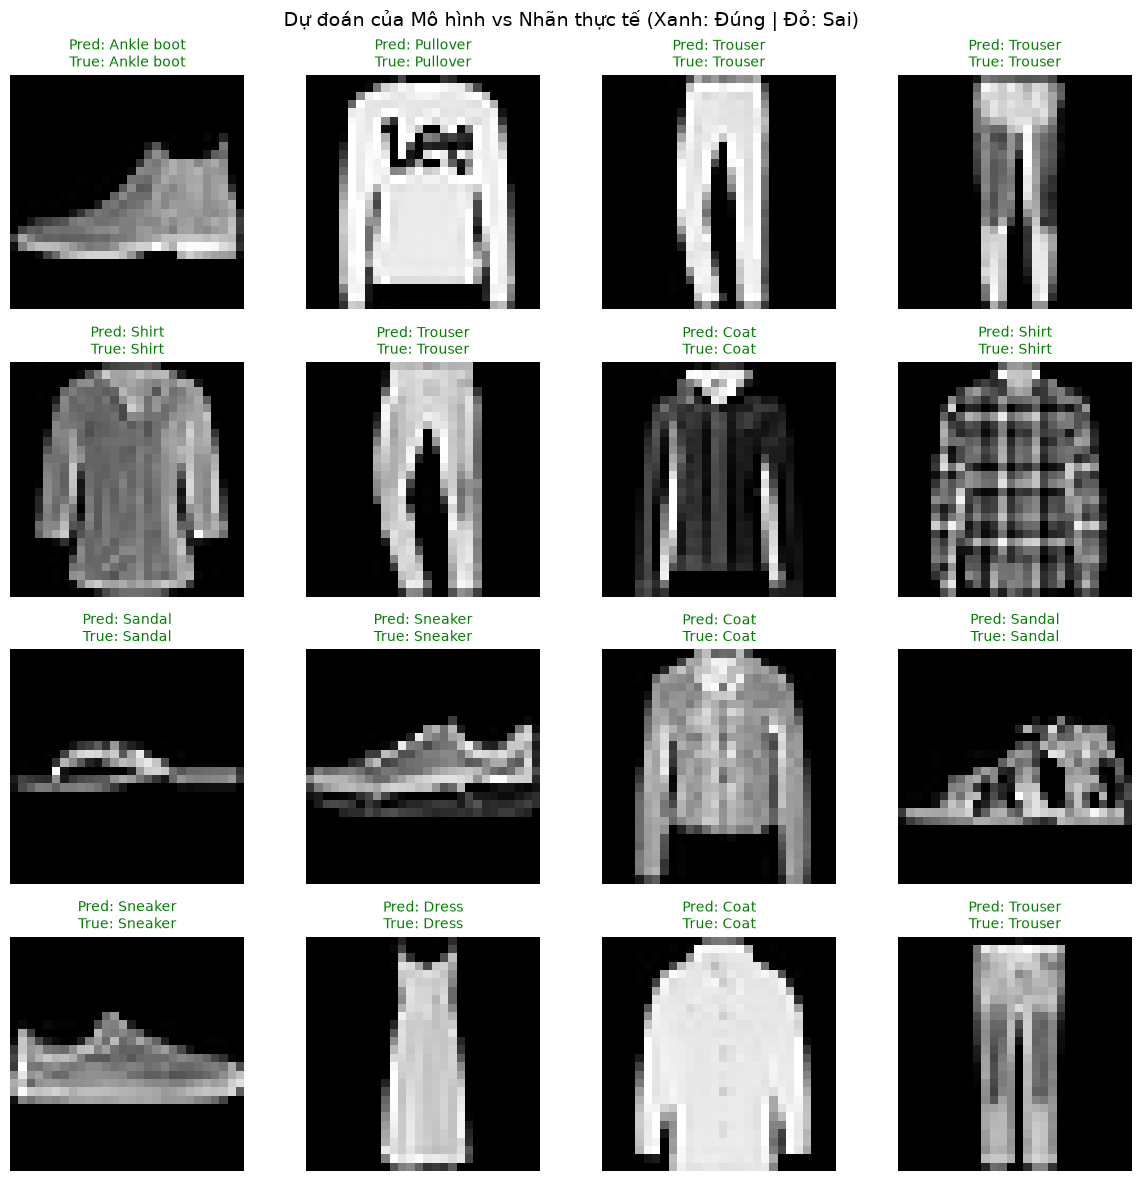

In [44]:
dataiter = iter(test_loader)
images, labels = next(dataiter)

images_dev = images.to(device)
outputs = loaded_model(images_dev)
_, preds = torch.max(outputs, 1)

images = images.numpy()
preds = preds.cpu().numpy()
labels = labels.numpy()

class_names = test_dataset.classes

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Dự đoán của Mô hình vs Nhãn thực tế (Xanh: Đúng | Đỏ: Sai)', fontsize=14)

for idx, ax in enumerate(axes.flatten()):
    img = images[idx].squeeze() * 0.5 + 0.5
    
    true_label = class_names[labels[idx]]
    pred_label = class_names[preds[idx]]
    
    ax.imshow(img, cmap='gray')
    
    color = 'green' if preds[idx] == labels[idx] else 'red'
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()